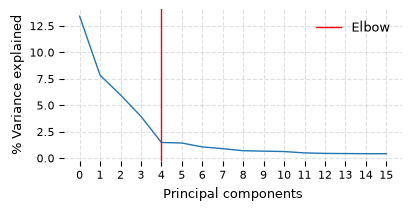

In [1]:
import scarf

scarf.set_verbosity('WARNING')

scarf.cytebase.connect("scarf_docs").download_dataset(
    'tenx_5K_pbmc_rnaseq',
    destination='scarf_datasets',
    zarr=True,
)
ds = scarf.DataStore(
    'scarf_datasets/tenx_5K_pbmc_rnaseq/data.zarr',
    nthreads=4,
    min_features_per_cell=10,
)
ds.filter_cells(
    attrs=['RNA_nCounts', 'RNA_nFeatures', 'RNA_percentMito'],
    highs=[15000, 4000, 15],
    lows=[1000, 500, 0],
    reset_previous=True,
)

if 'hvgs' not in ds.RNA.feats.columns:
    ds.mark_hvgs(min_cells=20, top_n=500, show_plot=False)
ds.make_graph(
    feat_key='hvgs',
    k=11,
    dims=15,
    n_centroids=100,
    show_elbow_plot=True,
)
if 'RNA_UMAP1' not in ds.cells.columns:
    ds.run_umap(n_epochs=150, spread=5, min_dist=1, parallel=True)
if 'RNA_leiden_cluster' not in ds.cells.columns:
    ds.run_leiden_clustering(resolution=0.5)

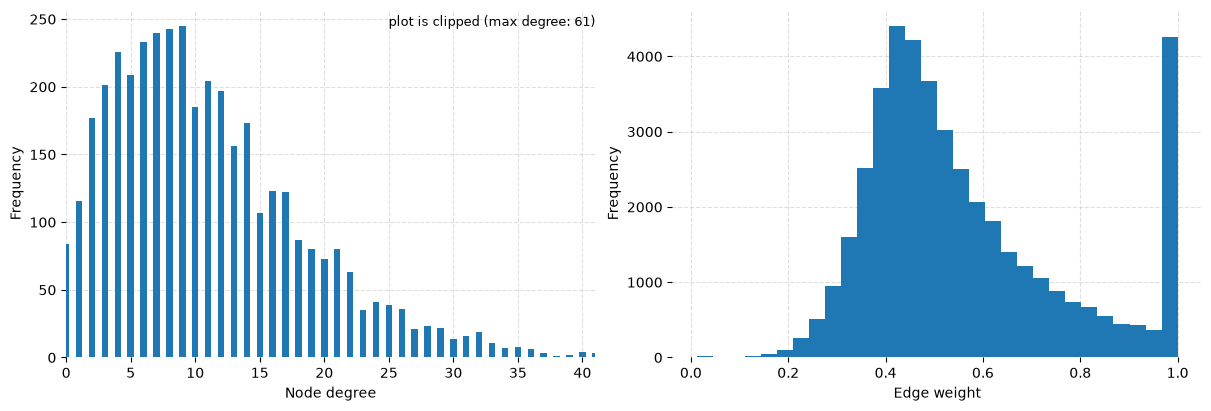

PlotResult(axes=2, tables=3, legends=2, scales=0, owns_figure=True, rendered=True)

In [2]:
import scarf.plotting as splt

graph = ds.load_graph(
    from_assay='RNA',
    cell_key='I',
    feat_key='hvgs',
    symmetric=False,
    upper_only=False,
)
splt.graph_qc(graph)

In [3]:
if 'RNA_densMAP1' not in ds.cells.columns:
    ds.run_umap(
        n_epochs=150,
        spread=5,
        min_dist=1,
        parallel=True,
        use_density_map=True,
        label='densMAP',
    )

In [4]:
if 'RNA_tSNE1' not in ds.cells.columns:
    ds.run_tsne(
        alpha=10,
        box_h=1,
        early_iter=250,
        max_iter=500,
    )

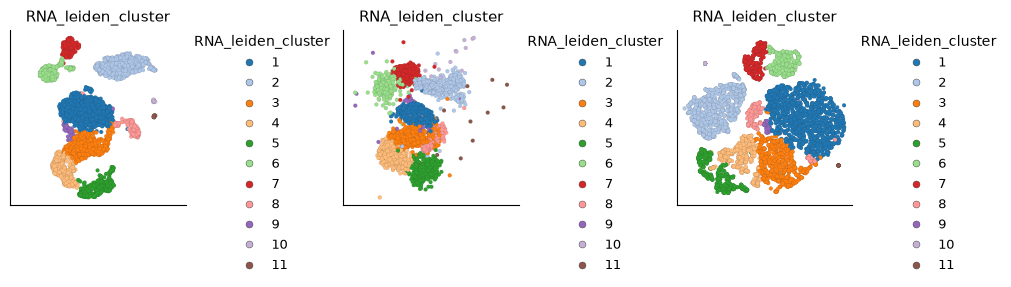

PlotResult(axes=3, tables=0, legends=3, scales=6, owns_figure=True, rendered=True)

In [5]:
layout_keys = [
    key for key in ['RNA_UMAP', 'RNA_densMAP', 'RNA_tSNE']
    if f'{key}1' in ds.cells.columns
]
ds.plots.embedding(
    layout_key=layout_keys,
    color_by='RNA_leiden_cluster',
    n_columns=len(layout_keys),
)

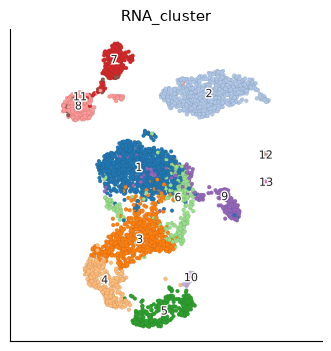

PlotResult(axes=1, tables=0, legends=1, scales=2, owns_figure=True, rendered=True)

In [6]:
n_clusters = int(
    ds.cells.to_pandas_dataframe(
        columns=['RNA_leiden_cluster'], key='I'
    )['RNA_leiden_cluster'].nunique()
)
ds.run_clustering(n_clusters=n_clusters)
ds.plots.embedding(
    layout_key='RNA_UMAP',
    color_by='RNA_cluster',
)

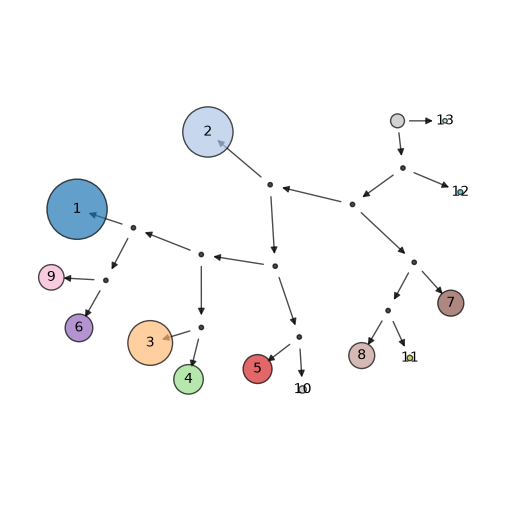

PlotResult(axes=1, tables=4, legends=1, scales=2, owns_figure=True, rendered=True)

In [7]:
ds.plots.cluster_tree(cluster_key='RNA_cluster', width=1)